# Phase 3 - Model bake-off (CICIDS2017)

We compare 7 supervised models, show all metrics and a confusion matrix for
each one, and keep the best model. A simple static rule baseline is also built
for comparison in Phase 4.

In [1]:
# imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

sns.set(style="whitegrid")
BASE = "/home/samouraifox/Work/stuff/S6/Notes_Ai/projet-final/model-building/Detection-explicable-danomalies"

In [2]:
# load the cleaned data
df = pd.read_parquet(BASE + "/data/processed/cicids_clean.parquet")
print("Data shape:", df.shape)
print(df["Label_binary"].value_counts())

Data shape: (2520798, 81)
Label_binary
0    2095057
1     425741
Name: count, dtype: int64


In [3]:
# features = all columns except the labels, target = Label_binary (0 = BENIGN, 1 = attack)
labels = ["Label", "Label_binary", "Label_group"]
features = [c for c in df.columns if c not in labels]
target = "Label_binary"

# drop constant columns (they carry no information)
stds = df[features].std()
features = [c for c in features if stds[c] != 0]
print("Number of features:", len(features))
joblib.dump(features, BASE + "/models/features.pkl")

Number of features: 70


['/home/samouraifox/Work/stuff/S6/Notes_Ai/projet-final/model-building/Detection-explicable-danomalies/models/features.pkl']

In [4]:
# train/test split (stratified to keep the same attack ratio in both sets)
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
print("Train:", X_train.shape[0], "Test:", X_test.shape[0])

Train: 1764558 Test: 756240


In [5]:
# scale the features (fit on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
joblib.dump(scaler, BASE + "/models/scaler.pkl")

['/home/samouraifox/Work/stuff/S6/Notes_Ai/projet-final/model-building/Detection-explicable-danomalies/models/scaler.pkl']

In [6]:
# BENIGN feature means (used in Phase 4 to explain alerts)
benign_means = X_train[y_train == 0].mean()
joblib.dump(benign_means, BASE + "/models/benign_means.pkl")

['/home/samouraifox/Work/stuff/S6/Notes_Ai/projet-final/model-building/Detection-explicable-danomalies/models/benign_means.pkl']

## Static rule baseline

A few fixed thresholds on raw features. A flow is flagged as an attack if at
least one rule fires (logical OR). It is a simplistic baseline, so we expect a
high false positive rate.

In [7]:
# thresholds near the high percentiles of BENIGN traffic
th_avg_packet_size = 496.0
th_bwd_packets_s = 58823.0
th_flow_packets_s = 500000.0
th_fwd_packets_short = 3
th_flow_duration_long = 1000000.0
th_flow_bytes_s = 12000000.0

# the 5 rules on the raw test set
r1 = X_test["Average Packet Size"] > th_avg_packet_size
r2 = X_test["Bwd Packets/s"] > th_bwd_packets_s
r3 = X_test["Flow Packets/s"] > th_flow_packets_s
r4 = (X_test["Total Fwd Packets"] <= th_fwd_packets_short) & (X_test["Flow Duration"] > th_flow_duration_long)
r5 = X_test["Flow Bytes/s"] > th_flow_bytes_s
y_pred_rule = (r1 | r2 | r3 | r4 | r5).astype(int)

cm_rule = confusion_matrix(y_test, y_pred_rule)
fp_rule = int(cm_rule[0, 1])
print("Rule baseline recall:", round(recall_score(y_test, y_pred_rule), 4))
print("Rule baseline false positives:", fp_rule)

Rule baseline recall: 0.6142
Rule baseline false positives: 97654


In [8]:
# save the rules (the keys are read by notebook 04 and the Streamlit app)
rule_baseline = {
    "description": "Static rules on raw features, attack if at least one rule fires (OR).",
    "logique": "OR",
    "regles": [
        {"feature": "Average Packet Size", "operateur": ">", "seuil": th_avg_packet_size,
         "justification": "High average packet size (DoS/DDoS floods)."},
        {"feature": "Bwd Packets/s", "operateur": ">", "seuil": th_bwd_packets_s,
         "justification": "High backward packet rate."},
        {"feature": "Flow Packets/s", "operateur": ">", "seuil": th_flow_packets_s,
         "justification": "Very high packet rate."},
        {"feature_1": "Total Fwd Packets", "operateur_1": "<=", "seuil_1": th_fwd_packets_short,
         "feature_2": "Flow Duration", "operateur_2": ">", "seuil_2": th_flow_duration_long,
         "justification": "Few forward packets but a long flow (probe)."},
        {"feature": "Flow Bytes/s", "operateur": ">", "seuil": th_flow_bytes_s,
         "justification": "Very high byte rate."},
    ],
    "recall_attaque_test": round(float(recall_score(y_test, y_pred_rule)), 4),
    "faux_positifs_test": fp_rule,
}
with open(BASE + "/models/rule_baseline.json", "w") as f:
    json.dump(rule_baseline, f, indent=2, ensure_ascii=False)

## The 7 models

We compare 7 supervised models. To keep the bake-off fast (KNN is slow on the
full data) we use a stratified subsample of the train set for the comparison,
then retrain the best model on the full train set at the end.

In [9]:
# stratified subsample of ~150000 train rows, then split it for the comparison
Xb, _, yb, _ = train_test_split(X_train_s, y_train, train_size=150000, random_state=42, stratify=y_train)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.3, random_state=42, stratify=yb)
print("Bake-off subsample:", Xb.shape[0], "rows")

Bake-off subsample: 150000 rows


In [10]:
# the 7 models
models = {
    "LinearSVC": LinearSVC(C=1, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=20, random_state=42),
    "Logistic Regression": LogisticRegression(C=10, max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(max_depth=8, learning_rate=0.1, n_estimators=300,
                             tree_method="hist", eval_metric="logloss", n_jobs=-1, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

## Cross-validation (10-fold, F1)

We compare the models with 10-fold cross-validation. We select on F1 because it
balances catching attacks (recall) and avoiding false alarms (precision):
selecting on recall alone would favor a model that flags everything as attack.
To prioritize catching attacks even more, change scoring to "recall".

In [11]:
# 10-fold cross-validation F1 for each model
scoring = "f1"
cv_f1_mean = {}
cv_f1_std = {}
print("=== Cross-validation (10-fold) ===")
for name, model in models.items():
    scores = cross_val_score(model, Xb_train, yb_train, cv=10, scoring=scoring)
    cv_f1_mean[name] = float(scores.mean())
    cv_f1_std[name] = float(scores.std())
    print(f"{name:20s} F1 = {scores.mean():.4f} +/- {scores.std():.4f}")

=== Cross-validation (10-fold) ===


LinearSVC            F1 = 0.8509 +/- 0.0094


Decision Tree        F1 = 0.9928 +/- 0.0014


Logistic Regression  F1 = 0.8694 +/- 0.0074


Naive Bayes          F1 = 0.3616 +/- 0.0085


Random Forest        F1 = 0.9937 +/- 0.0012


XGBoost              F1 = 0.9960 +/- 0.0011


KNN                  F1 = 0.9643 +/- 0.0026


## All metrics and confusion matrix for each model

We train each model on the bake-off train set and look at accuracy, precision,
recall and F1 on the bake-off test set, plus its confusion matrix.

In [12]:
# train each model and compute all metrics on the test set
results = {}
preds = {}
for name, model in models.items():
    model.fit(Xb_train, yb_train)
    y_pred = model.predict(Xb_test)
    preds[name] = y_pred
    results[name] = {
        "Accuracy": accuracy_score(yb_test, y_pred),
        "Precision": precision_score(yb_test, y_pred, zero_division=0),
        "Recall": recall_score(yb_test, y_pred, zero_division=0),
        "F1": f1_score(yb_test, y_pred, zero_division=0),
    }

metrics_df = pd.DataFrame(results).T
print("=== All metrics for each model (bake-off test set) ===")
print(metrics_df.round(4))

=== All metrics for each model (bake-off test set) ===
                     Accuracy  Precision  Recall      F1
LinearSVC              0.9513     0.8712  0.8351  0.8528
Decision Tree          0.9982     0.9927  0.9967  0.9947
Logistic Regression    0.9572     0.8817  0.8621  0.8718
Naive Bayes            0.3972     0.2181  0.9942  0.3578
Random Forest          0.9984     0.9949  0.9954  0.9951
XGBoost                0.9986     0.9944  0.9976  0.9960
KNN                    0.9882     0.9655  0.9649  0.9652


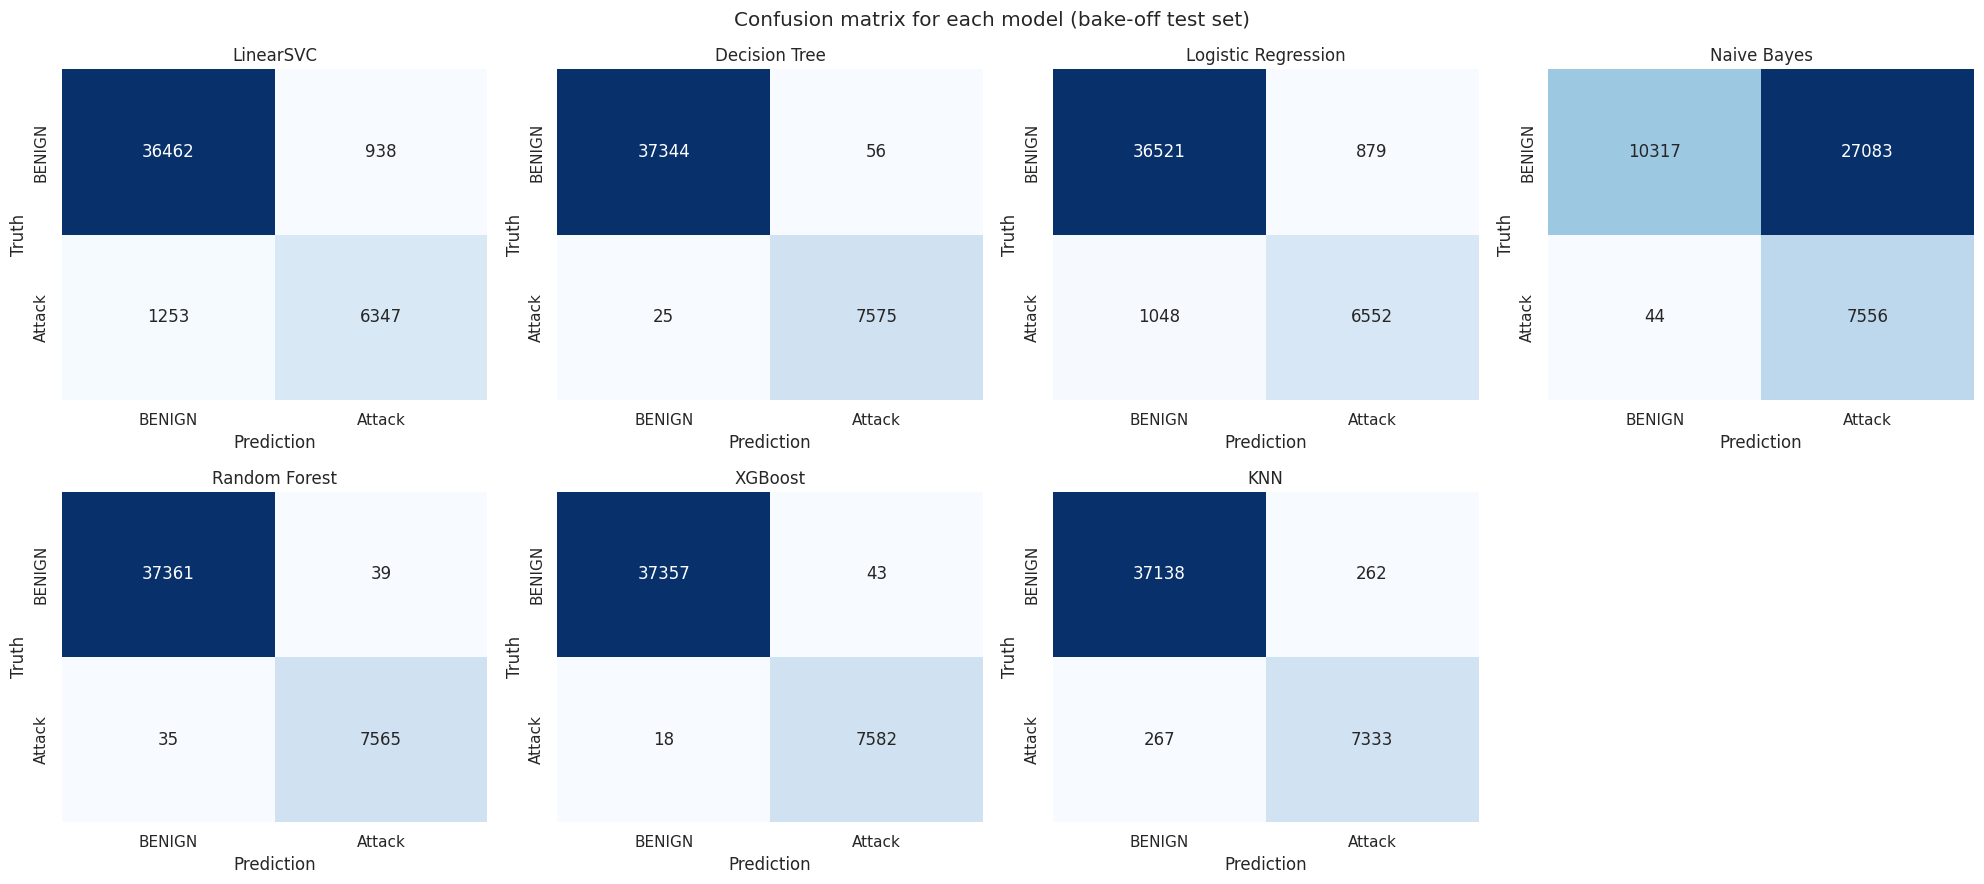

In [13]:
# confusion matrix for each model
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()
for i, name in enumerate(models):
    cm = confusion_matrix(yb_test, preds[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["BENIGN", "Attack"], yticklabels=["BENIGN", "Attack"], ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Prediction")
    axes[i].set_ylabel("Truth")
axes[7].axis("off")  # 7 models, 8 cells: hide the last one
plt.suptitle("Confusion matrix for each model (bake-off test set)")
plt.tight_layout()
plt.savefig(BASE + "/reports/figures/12_confusion_matrices.png", dpi=120)
plt.show()

## Keep the best model

The best model is the one with the highest cross-validation F1. We save the
results table, retrain the best model on the full train set, and save it.

In [14]:
# best model = highest cross-validation F1
best_name = max(cv_f1_mean, key=cv_f1_mean.get)
print("Best model:", best_name)
print(metrics_df.loc[best_name].round(4))

Best model: XGBoost
Accuracy     0.9986
Precision    0.9944
Recall       0.9976
F1           0.9960
Name: XGBoost, dtype: float64


In [15]:
# save the results table (cross-validation F1 + test metrics), used by notebook 04
cv_results = {}
for name in models:
    cv_results[name] = {
        "cv_f1_mean": round(cv_f1_mean[name], 4),
        "cv_f1_std": round(cv_f1_std[name], 4),
        "accuracy": round(results[name]["Accuracy"], 4),
        "precision": round(results[name]["Precision"], 4),
        "recall": round(results[name]["Recall"], 4),
        "f1": round(results[name]["F1"], 4),
        "selected": name == best_name,
    }
with open(BASE + "/models/cv_results.json", "w") as f:
    json.dump(cv_results, f, indent=2, ensure_ascii=False)

In [16]:
# retrain the best model on the full train set, then save it
best_model = models[best_name]
best_model.fit(X_train_s, y_train)
joblib.dump(best_model, BASE + "/models/best_model.pkl")

best_model_meta = {
    "name": best_name,
    "cv_f1_mean": round(cv_f1_mean[best_name], 4),
    "cv_f1_std": round(cv_f1_std[best_name], 4),
}
with open(BASE + "/models/best_model_meta.json", "w") as f:
    json.dump(best_model_meta, f, indent=2, ensure_ascii=False)
print("Best model retrained on the full train set and saved.")

Best model retrained on the full train set and saved.


## Quick check of the best model on the full test set

In [17]:
y_pred_best = best_model.predict(X_test_s)
print("Best model on the full test set:")
print("Accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print("Recall:  ", round(recall_score(y_test, y_pred_best), 4))
print("F1:      ", round(f1_score(y_test, y_pred_best), 4))
print(confusion_matrix(y_test, y_pred_best))

Best model on the full test set:
Accuracy: 0.9992
Recall:   0.9987


F1:       0.9976
[[628080    438]
 [   163 127559]]


## Save the test set and a small sample for the dashboard

In [18]:
# full test set (raw features + labels) for Phase 4
test_cols = features + ["Label", "Label_binary", "Label_group"]
df_test = df.loc[X_test.index, test_cols]
df_test.to_parquet(BASE + "/data/processed/test_set.parquet", index=False)
print("Test set saved:", df_test.shape)

Test set saved: (756240, 73)


In [19]:
# small stratified sample (~3000 rows per family) for the Streamlit app
parts = []
for group, rows in df_test.groupby("Label_group"):
    parts.append(rows.sample(n=min(len(rows), 3000), random_state=42))
app_sample = pd.concat(parts, ignore_index=True)
app_sample.to_parquet(BASE + "/data/processed/app_sample.parquet", index=False)
print("App sample saved:", app_sample.shape)

App sample saved: (15937, 73)
